In [1]:
import ast
import pandas as pd
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']= pd.to_datetime(df.job_posted_date)
import matplotlib.pyplot as plt

df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df = df[df['job_title_short'] == 'Data Analyst']

In [12]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

skills_stats= skill_stats.sort_values(by= 'skill_count', ascending= False).head(10)

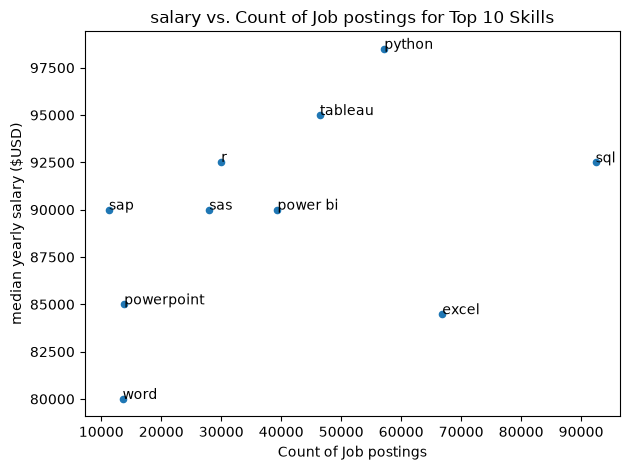

In [22]:
skills_stats.plot(kind = 'scatter', x= 'skill_count', y= 'median_salary')
plt.xlabel('Count of Job postings')
plt.ylabel ("median yearly salary ($USD)")
plt.title('salary vs. Count of Job postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt)
plt.show()